In [1]:
import numpy as np
import pandas as pd
import os, shutil, pathlib
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, smart_resize

In [2]:
p = Path().cwd()
q = p.joinpath('archive', 'train')

target_dict = {'Closed' : 0, 'Open' : 1, 'no_yawn' : 2, 'yawn' : 3}

images = [] # create an empty list
labels = [] # create an empty list

for fldr in q.iterdir(): 
    current_label = fldr.name
    for img in fldr.iterdir():
        img = load_img(img) 
        img_array =  img_to_array(img) # convert the image to an NumPy array 
        img_array_resized =  smart_resize(img_array, (128, 128)) # if necessary, resize the image to 128 by 128 
        img_array_reshaped = img_array_resized.reshape(128, 128, 3) # reshape  image to (height, width, 3) from (height, width)
        images.append(img_array_reshaped) # add reshaped image to list of images 
        labels.append(target_dict[current_label]) # add label for this image to the list of labels 

In [3]:
images = np.array(images) # convert the list of images to a NumPy array 
labels = np.array(labels) # convert the list of labels to a NumPy array

In [4]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels) # use the target_dict to convert the string labels to an array of integers

In [5]:
# Normalising the Images data - Divide by 255 in order to get the pixel values between 0 - 1.

images = images.astype('float32') / 255

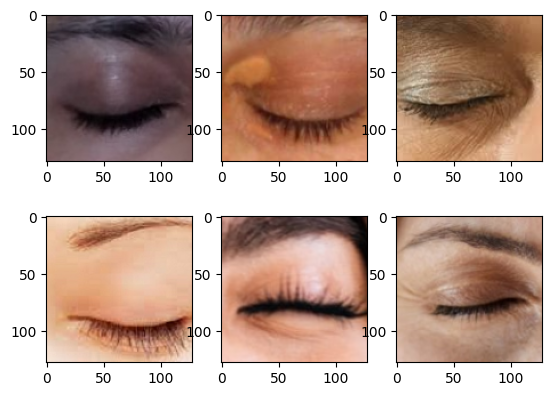

In [6]:
# Displaying the first 6 train_images

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
plt.show()

# From scratch

In [7]:
from sklearn.model_selection import train_test_split
train_images, test_images, train_labels, test_labels  = train_test_split(images,labels, test_size=0.1)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.2)

In [8]:
print(f'train_images : ',train_images.shape)
print(f'valid_images : ',valid_images.shape)
print(f'test_images  : ',test_images.shape)
print('-------------------------------')
print(f'train_labels : ',train_labels.shape)
print(f'valid_labels : ',valid_labels.shape)
print(f'test_labels  : ',test_labels.shape)

train_images :  (2088, 128, 128, 3)
valid_images :  (522, 128, 128, 3)
test_images  :  (290, 128, 128, 3)
-------------------------------
train_labels :  (2088, 4)
valid_labels :  (522, 4)
test_labels  :  (290, 4)


In [9]:
# Importing the required Libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

# Building a Baseline Model

In [10]:
#1. Constructing a CNN Model Network
Baseline_model = Sequential([
    Conv2D(filters = 32, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(20, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
Baseline_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

#3. Fitting the Model
Baseline_model.fit(train_images,train_labels, epochs=12, validation_data=(valid_images,valid_labels), batch_size=64)
test_loss, test_acc = Baseline_model.evaluate(test_images, test_labels)
print('\nTest Accuracy:', test_acc, '\nTest Loss', test_loss)

Epoch 1/12
33/33 [==============================] - 12s 66ms/step - loss: 1.3414 - accuracy: 0.5469 - val_loss: 0.6465 - val_accuracy: 0.7165
Epoch 2/12
33/33 [==============================] - 1s 20ms/step - loss: 0.5149 - accuracy: 0.7830 - val_loss: 0.4791 - val_accuracy: 0.7950
Epoch 3/12
33/33 [==============================] - 1s 18ms/step - loss: 0.4105 - accuracy: 0.8357 - val_loss: 0.4466 - val_accuracy: 0.8180
Epoch 4/12
33/33 [==============================] - 1s 17ms/step - loss: 0.2954 - accuracy: 0.8937 - val_loss: 0.3740 - val_accuracy: 0.8525
Epoch 5/12
33/33 [==============================] - 1s 17ms/step - loss: 0.2692 - accuracy: 0.9004 - val_loss: 0.4972 - val_accuracy: 0.7950
Epoch 6/12
33/33 [==============================] - 1s 17ms/step - loss: 0.2334 - accuracy: 0.9171 - val_loss: 0.3469 - val_accuracy: 0.8697
Epoch 7/12
33/33 [==============================] - 1s 17ms/step - loss: 0.1777 - accuracy: 0.9459 - val_loss: 0.2945 - val_accuracy: 0.8697
Epoch 8/12
3

# Data Augumentation

### Import Required Libraries

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
#1. Constructing a CNN Model Network

# CN Network
Final_model = Sequential([
    Conv2D(filters = 64, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
#    Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same'),
#    BatchNormalization(),
#    MaxPooling2D(pool_size=(2,2)),
    
# Dense Network    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.03),
#    Dense(64, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
opt=Adam(learning_rate=0.001)
Final_model.compile(optimizer=opt, loss = 'categorical_crossentropy', metrics = ['accuracy'])


#3. Fitting the Model
callbacks = ModelCheckpoint(filepath="convnet_from_scratch.keras", save_best_only=True, monitor="val_loss")

data_augmentation = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, 
                                       zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

Final_output = Final_model.fit(data_augmentation.flow(train_images,train_labels, batch_size=32), epochs=12, 
                               validation_data=(valid_images,valid_labels), batch_size=32, callbacks=[callbacks])

test_loss, test_acc = Final_model.evaluate(test_images, test_labels)

print('\nTest Accuracy:', test_acc, '\nTest Loss   :', test_loss)

Epoch 1/12
66/66 [==============================] - 8s 109ms/step - loss: 4.8937 - accuracy: 0.5551 - val_loss: 1.0984 - val_accuracy: 0.5000
Epoch 2/12
66/66 [==============================] - 5s 74ms/step - loss: 0.5981 - accuracy: 0.6777 - val_loss: 0.9505 - val_accuracy: 0.6379
Epoch 3/12
66/66 [==============================] - 5s 81ms/step - loss: 0.5720 - accuracy: 0.7107 - val_loss: 0.8684 - val_accuracy: 0.6264
Epoch 4/12
66/66 [==============================] - 5s 77ms/step - loss: 0.5659 - accuracy: 0.7079 - val_loss: 0.8229 - val_accuracy: 0.6130
Epoch 5/12
66/66 [==============================] - 5s 80ms/step - loss: 0.5867 - accuracy: 0.6949 - val_loss: 0.7059 - val_accuracy: 0.7280
Epoch 6/12
66/66 [==============================] - 5s 72ms/step - loss: 0.5345 - accuracy: 0.7289 - val_loss: 0.6565 - val_accuracy: 0.6973
Epoch 7/12
66/66 [==============================] - 5s 78ms/step - loss: 0.5275 - accuracy: 0.7198 - val_loss: 0.5568 - val_accuracy: 0.7414
Epoch 8/12
6

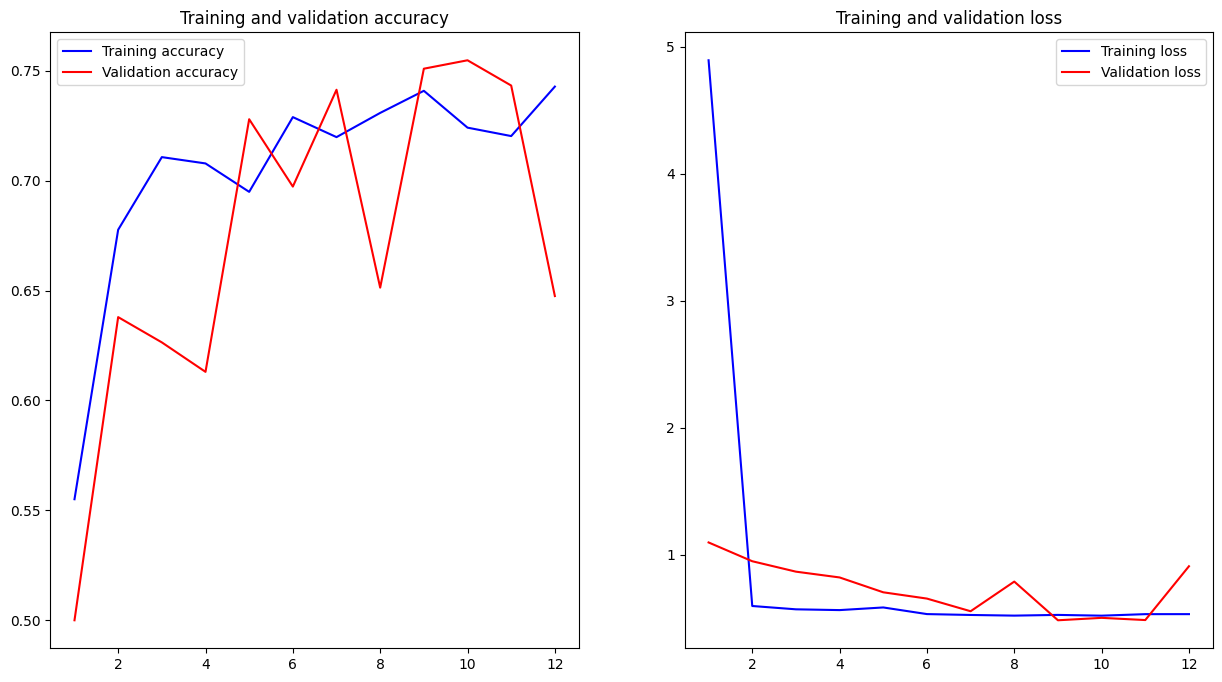

In [13]:
accuracy = Final_output.history["accuracy"]
val_accuracy = Final_output.history["val_accuracy"]

loss = Final_output.history["loss"]
val_loss = Final_output.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Building a Final Model

In [14]:
#1. Constructing a CNN Model Network

# CN Network
Final_model = Sequential([
    Conv2D(filters = 64, kernel_size=(3,3),activation='relu', padding = 'same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(filters = 32, kernel_size = (3,3), activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    
# Dense Network    
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.03),
    Dense(64, activation = 'relu'),
    Dense(4, activation = 'softmax')])

#2. Compiling the Model
#opt=Adam(learning_rate=0.003)
Final_model.compile(optimizer=Adam(learning_rate=0.003), loss = 'categorical_crossentropy', metrics = ['accuracy'])


#3. Fitting the Model
callbacks = ModelCheckpoint(filepath="convnet_from_scratch.keras", save_best_only=True, monitor="val_loss")

Final_output = Final_model.fit(train_images,train_labels, epochs=25, validation_data=(valid_images,valid_labels), batch_size=32,
                               callbacks=[callbacks])
test_loss, test_acc = Final_model.evaluate(test_images, test_labels)
print('\nTest Accuracy:', test_acc, '\nTest Loss   :', test_loss)

Epoch 1/25
66/66 [==============================] - 2s 29ms/step - loss: 4.1525 - accuracy: 0.6806 - val_loss: 6.9303 - val_accuracy: 0.3008
Epoch 2/25
66/66 [==============================] - 1s 22ms/step - loss: 1.0635 - accuracy: 0.7701 - val_loss: 17.8016 - val_accuracy: 0.3448
Epoch 3/25
66/66 [==============================] - 1s 21ms/step - loss: 0.6556 - accuracy: 0.7854 - val_loss: 19.7542 - val_accuracy: 0.3238
Epoch 4/25
66/66 [==============================] - 2s 23ms/step - loss: 0.3957 - accuracy: 0.8415 - val_loss: 3.7857 - val_accuracy: 0.5172
Epoch 5/25
66/66 [==============================] - 1s 22ms/step - loss: 0.3830 - accuracy: 0.8539 - val_loss: 1.0355 - val_accuracy: 0.6935
Epoch 6/25
66/66 [==============================] - 1s 22ms/step - loss: 0.2852 - accuracy: 0.8683 - val_loss: 0.5492 - val_accuracy: 0.7759
Epoch 7/25
66/66 [==============================] - 1s 21ms/step - loss: 0.2179 - accuracy: 0.9109 - val_loss: 0.6174 - val_accuracy: 0.7854
Epoch 8/25


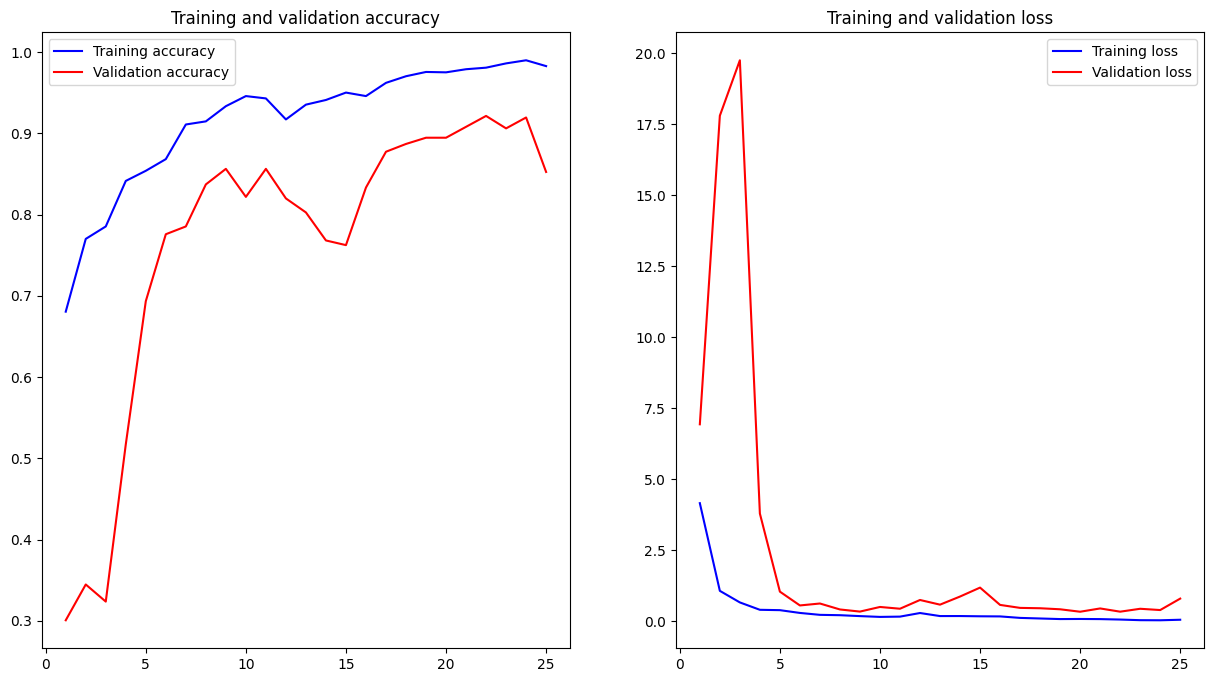

In [15]:
import matplotlib.pyplot as plt

accuracy = Final_output.history["accuracy"]
val_accuracy = Final_output.history["val_accuracy"]

loss = Final_output.history["loss"]
val_loss = Final_output.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [17]:
from tabulate import tabulate

# Sample data in the form of a list of lists
data = [
    ["Baseline CNN",97.94,85.52,1,2622398,12,32],
    ["Augumented CNN",74.28,65.17,2,33556866,12,32],
    ["Finalized CNN",98.28,86.20,2,4223458,25,32],
    
]

# Table headers
headers = ["Model", "Accuracy(Train-in%)","Accuracy(Test-in%)","Total layers","Total params","epoch","batch size"]

print(tabulate(data, headers=headers))

Model             Accuracy(Train-in%)    Accuracy(Test-in%)    Total layers    Total params    epoch    batch size
--------------  ---------------------  --------------------  --------------  --------------  -------  ------------
Baseline CNN                    97.94                 85.52               1         2622398       12            32
Augumented CNN                  74.28                 65.17               2        33556866       12            32
Finalized CNN                   98.28                 86.2                2         4223458       25            32
